# Perspic Analyzer Demo

This notebook demonstrates how to use the `perspic` analyzer to instrument a PyTorch Lightning model.
The analyzer wraps your model and automatically tracks additional metrics (Collective Variables) during training, providing deeper insights into the training dynamics without requiring manual instrumentation.

We will:
1. Setup a standard CIFAR-10 training pipeline.
2. Wrap the model with `analyzer`.
3. Train the model and visualize the additional metrics captured by `perspic`.

**Note:** We set `log_every_n_steps=1` in the `Trainer` to capture high-resolution dynamics for every training step. This allows us to visualize the full noise and convergence behavior of the gradients and coupling coefficient.

In [ ]:
import os

import pandas as pd
import pytorch_lightning as pl
import seaborn as sn
import torch
import torchvision
from IPython.display import display
from pytorch_lightning.callbacks import LearningRateMonitor
from pytorch_lightning.loggers import CSVLogger
from torch.utils.data import DataLoader, random_split
from torchvision.datasets import CIFAR10

from perspic.analyzer import analyzer
from examples.models import BatchNormMLP, ClassificationModule, WideResNet

import matplotlib.pyplot as plt

pl.seed_everything(7)

PATH_DATASETS = os.environ.get("PATH_DATASETS", ".")
BATCH_SIZE = 256 if torch.cuda.is_available() else 64
NUM_WORKERS = int(os.cpu_count() / 2)

Seed set to 7


In [2]:
# Define transforms
# CIFAR10 mean and std
stats = ((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
train_transform = torchvision.transforms.Compose([
    torchvision.transforms.RandomCrop(32, padding=4),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(*stats),
])
test_transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(*stats),
])

# Load datasets
# We instantiate the dataset twice to apply different transforms to train and val splits
train_dataset_full = CIFAR10(PATH_DATASETS, train=True, download=True, transform=train_transform)
val_dataset_full = CIFAR10(PATH_DATASETS, train=True, download=True, transform=test_transform)
test_set = CIFAR10(PATH_DATASETS, train=False, download=True, transform=test_transform)

# Split train/val (45k/5k)
# We use the same seed to ensure the split indices are identical for both dataset instances
generator = torch.Generator().manual_seed(42)
train_set, _ = random_split(train_dataset_full, [45000, 5000], generator=generator)
_, val_set = random_split(val_dataset_full, [45000, 5000], generator=generator)

# DataLoaders
# We set drop_last=True to avoid spikes in gradient norms caused by smaller last batches
train_dataloader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, drop_last=True)
val_dataloader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, drop_last=True)
test_dataloader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, drop_last=True)

## Model Instrumentation

Here is the core of `perspic`. Instead of just instantiating your `LightningModule`, you wrap it with the `analyzer` function.
This wrapper injects the necessary hooks to calculate sample-wise metrics (using `functorch` in this example) and logs them automatically.

In [3]:
# Wrap the model with the analyzer
# This adds the capability to track additional metrics (like gradients) during training
model = analyzer(
    lightning_module=ClassificationModule, 
    sample_wise_engine="functorch", 
    # model=BatchNormMLP(), 
    model=WideResNet(10, 10),
    lr=0.05
)

In [4]:

trainer = pl.Trainer(
    max_epochs=5,
    accelerator="auto",
    devices=1,
    logger=CSVLogger(save_dir="logs/"),
    callbacks=[LearningRateMonitor(logging_interval="step")],
    log_every_n_steps=1,
)

trainer.fit(model, train_dataloaders=train_dataloader, val_dataloaders=val_dataloader)
trainer.test(model, dataloaders=test_dataloader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


You are using a CUDA device ('NVIDIA GeForce RTX 3090 Ti') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name  | Type       | Params | Mode 
---------------------------------------------
0 | model | WideResNet | 77.9 K | train
---------------------------------------------
77.9 K    Trainable params
0         Non-trainable params
77.9 K    Total params
0.311     Total estimated model params size (MB)
34        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

/data/knikolaou/software/miniconda3/envs/lightning/lib/python3.11/site-packages/torch/autograd/graph.py:823: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:180.)


...

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=5` reached.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.6726762652397156
        test_loss           0.9561811685562134
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 0.9561811685562134, 'test_acc': 0.6726762652397156}]

Tracked Metrics:


,actual_batch_size,batch_grad_norms_loss,batch_grad_norms_network,coupling_value,delta_loss,epoch,loss_value,lr-Adam,perturbed_loss_value,step,test_acc,test_loss,train_acc,train_loss,val_acc,val_loss
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.05,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN
1,256.0,0.003521,129404.304688,0.000733,-0.000003,0.0,2.312427,NaN,2.312423,0,NaN,NaN,0.121094,2.312427,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.05,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN
3,256.0,0.003687,523901.750000,0.011467,-0.000221,0.0,2.597924,NaN,2.597702,1,NaN,NaN,0.125000,2.597924,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.05,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN


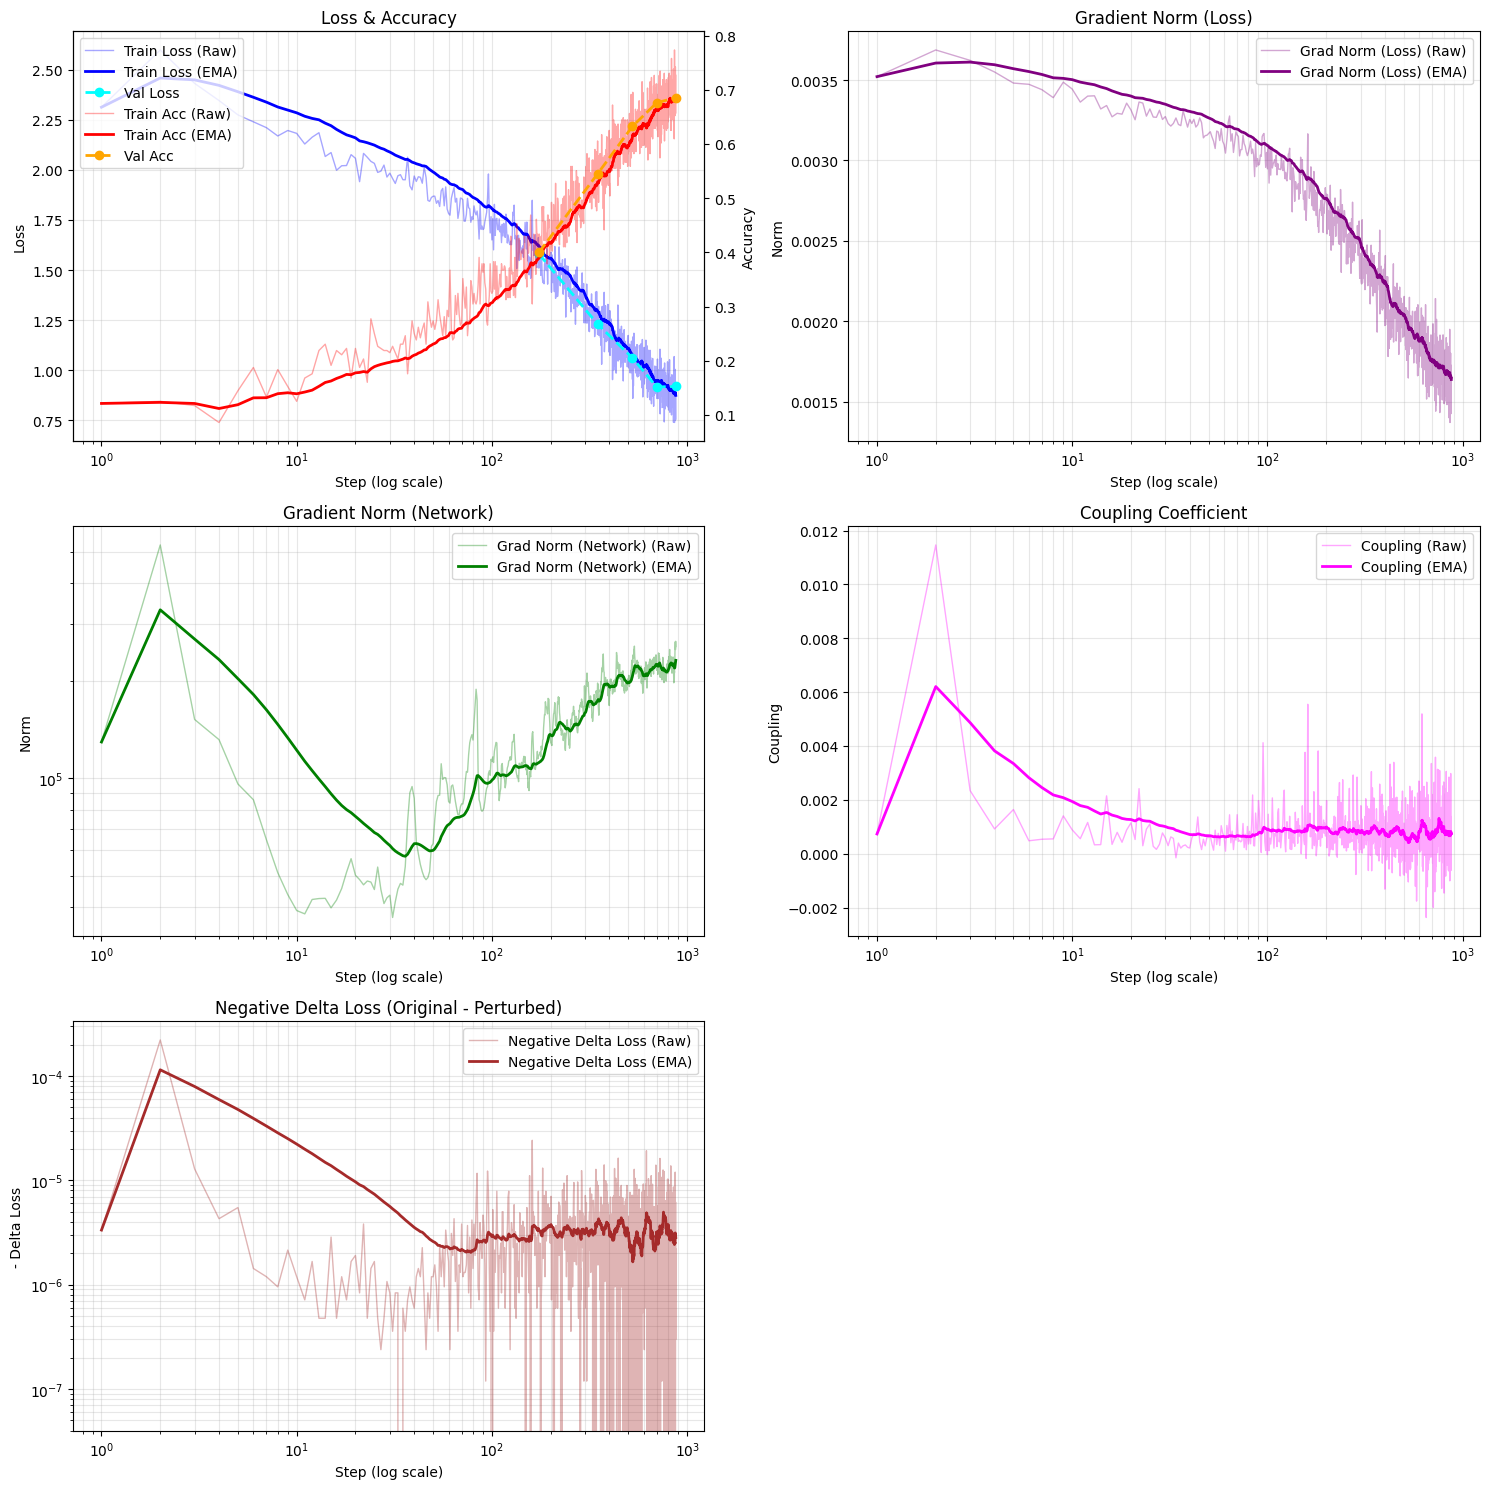

In [ ]:
# --- 1. Load and Prepare Data ---
metrics = pd.read_csv(f"{trainer.logger.log_dir}/metrics.csv")

# Display first few rows to show what's being tracked
print("Tracked Metrics:")
display(metrics.dropna(axis=1, how="all").head())

# --- 2. Helper Functions ---
def plot_metric(ax, data, column, label, color, alpha=0.35, ema_span=50, negate=False):
    """
    Plots raw data with transparency and an Exponential Moving Average (EMA) overlay.
    
    Args:
        ax: Matplotlib axes object.
        data: DataFrame containing the metrics.
        column: Name of the column to plot.
        label: Label for the legend.
        color: Color of the plot.
        alpha: Transparency for the raw data.
        ema_span: Span for the EMA calculation.
        negate: If True, plots the negative of the values.
    """
    # Filter and sort data
    subset = data[[column, "step"]].dropna().sort_values("step")
    
    # Handle log(0) issue by shifting steps if they start at 0
    steps = subset["step"]
    if steps.min() == 0:
        steps = steps + 1
        
    values = subset[column].values
    if negate:
        values = -values
        
    series = pd.Series(values, index=steps)
    
    # Plotting Logic
    if len(series) > 50: 
        # High-frequency data: Plot Raw (noisy) + EMA (smooth)
        ax.plot(series.index, series.values, color=color, alpha=alpha, linewidth=1, label=f"{label} (Raw)")
        ema = series.ewm(span=ema_span).mean()
        ax.plot(series.index, ema.values, color=color, label=f"{label} (EMA)", linewidth=2)
    else:
        # Low-frequency data (e.g. validation): Plot markers
        ax.plot(series.index, series.values, color=color, label=label, marker='o', linestyle='--', linewidth=2)

def configure_axis(ax, title, ylabel, xlabel="Step (log scale)", xscale="log", yscale="linear"):
    """Configures the appearance of a subplot axis."""
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel(xlabel)
    ax.set_xscale(xscale)
    ax.set_yscale(yscale)
    ax.grid(True, alpha=0.3, which="both")
    # Only add legend if there are labeled artists
    if ax.get_legend_handles_labels()[0]:
        ax.legend(loc="best")

# --- 3. Plotting Configuration ---
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
axes = axes.flatten()

# --- 4. Generate Subplots ---

# Subplot 1: Loss & Accuracy
ax_loss = axes[0]
if "train_loss" in metrics.columns:
    plot_metric(ax_loss, metrics, "train_loss", "Train Loss", "blue")
if "val_loss" in metrics.columns:
    plot_metric(ax_loss, metrics, "val_loss", "Val Loss", "cyan")

configure_axis(ax_loss, "Loss & Accuracy", "Loss")

# Add Accuracy on secondary axis
if "train_acc" in metrics.columns or "val_acc" in metrics.columns:
    ax_acc = ax_loss.twinx()
    if "train_acc" in metrics.columns:
        plot_metric(ax_acc, metrics, "train_acc", "Train Acc", "red")
    if "val_acc" in metrics.columns:
        plot_metric(ax_acc, metrics, "val_acc", "Val Acc", "orange")
    ax_acc.set_ylabel("Accuracy")
    # Combine legends from both axes
    lines_1, labels_1 = ax_loss.get_legend_handles_labels()
    lines_2, labels_2 = ax_acc.get_legend_handles_labels()
    ax_loss.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")


# Subplot 2: Gradient Norm (Loss)
ax_grad_loss = axes[1]
if "batch_grad_norms_loss" in metrics.columns:
    plot_metric(ax_grad_loss, metrics, "batch_grad_norms_loss", "Grad Norm (Loss)", "purple")
configure_axis(ax_grad_loss, "Gradient Norm (Loss)", "Norm")


# Subplot 3: Gradient Norm (Network)
ax_grad_net = axes[2]
if "batch_grad_norms_network" in metrics.columns:
    plot_metric(ax_grad_net, metrics, "batch_grad_norms_network", "Grad Norm (Network)", "green")
configure_axis(ax_grad_net, "Gradient Norm (Network)", "Norm", yscale="log")


# Subplot 4: Coupling Coefficient
ax_coupling = axes[3]
if "coupling_value" in metrics.columns:
    plot_metric(ax_coupling, metrics, "coupling_value", "Coupling", "magenta")
configure_axis(ax_coupling, "Coupling Coefficient", "Coupling")


# Subplot 5: Negative Delta Loss
ax_delta = axes[4]
if "delta_loss" in metrics.columns:
    plot_metric(ax_delta, metrics, "delta_loss", "Negative Delta Loss", "brown", negate=True)
configure_axis(ax_delta, "Negative Delta Loss (Original - Perturbed)", "- Delta Loss", yscale="log")


# Subplot 6: Unused
if len(axes) > 5:
    axes[5].axis('off')

plt.tight_layout()
plt.show()